Dataset= https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database

**PROBLEM STATEMENT**

A hospital wants to screen patients for diabetes risk based on diagnostic measurements. Build a logistic
regression classifier to predict whether a patient is diabetic or not, and evaluate its clinical performance

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
roc_auc_score, roc_curve, auc)



1. LOAD & CLEAN

In [5]:
df = pd.read_csv("/content/diabetes (1).csv")
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[zero_cols] = df[zero_cols].replace(0, np.nan)
df.fillna(df.median(), inplace=True)
X = df.drop('Outcome', axis=1) # Features
y = df['Outcome'] # Target (0=no diabetes, 1=diabetes)
# Check class balance
print("Class distribution:")
print(y.value_counts())
print(f"Imbalance ratio: {y.value_counts()[0]/y.value_counts()[1]:.2f}:1")


Class distribution:
Outcome
0    500
1    268
Name: count, dtype: int64
Imbalance ratio: 1.87:1


 SCALE FEATURES

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X) # Mean=0, Std=1 for each feature


3. TRAIN-TEST SPLIT

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
X_scaled, y, test_size=0.2, random_state=42, stratify=y
)
# stratify=y preserves class ratio in both train and test sets


4. BUILD MODEL

In [8]:
model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

5. EVALUATE

In [9]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1] # Probability of class 1
print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred,
target_names=['Non-Diabetic', 'Diabetic']))
print(f"AUC-ROC Score: {roc_auc_score(y_test, y_prob):.4f}")


=== Classification Report ===
              precision    recall  f1-score   support

Non-Diabetic       0.82      0.75      0.79       100
    Diabetic       0.60      0.70      0.65        54

    accuracy                           0.73       154
   macro avg       0.71      0.73      0.72       154
weighted avg       0.75      0.73      0.74       154

AUC-ROC Score: 0.8126


 CONFUSION MATRIX

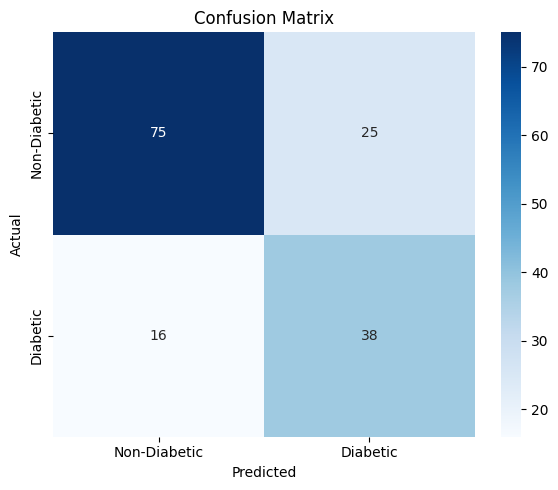

In [10]:
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
xticklabels=['Non-Diabetic', 'Diabetic'],
yticklabels=['Non-Diabetic', 'Diabetic'])
plt.title("Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

 7. ROC CURVE


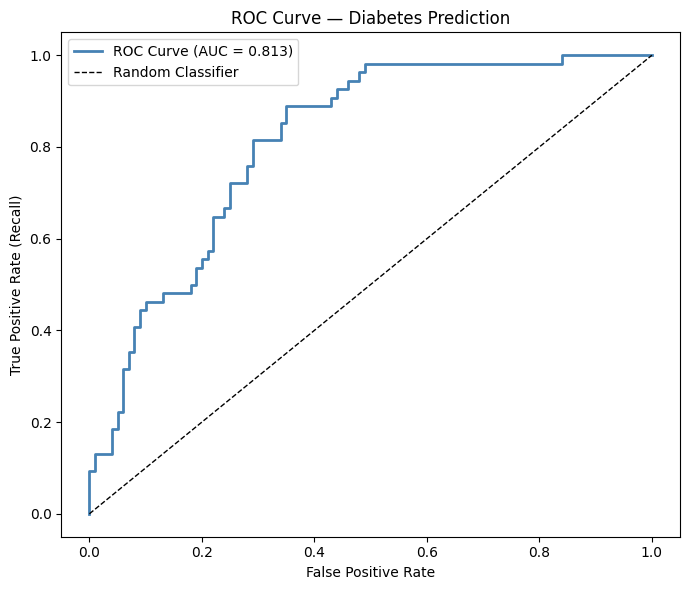

In [11]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='steelblue', lw=2,
label=f'ROC Curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve — Diabetes Prediction")
plt.legend()
plt.tight_layout()
plt.savefig("roc_curve.png", dpi=150)
plt.show()

8. FEATURE IMPORTANCE (COEFFICIENTS)

<Figure size 800x500 with 0 Axes>

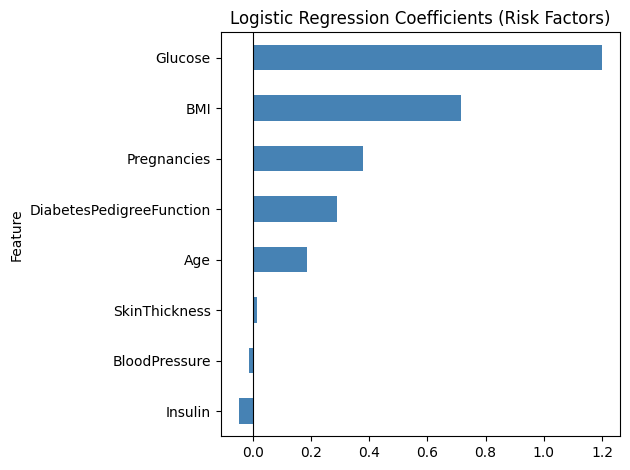

In [12]:
coef_df = pd.DataFrame({
'Feature': X.columns,
'Coefficient': model.coef_[0]
}).sort_values('Coefficient', ascending=True)
plt.figure(figsize=(8, 5))
coef_df.plot(kind='barh', x='Feature', y='Coefficient',
color='steelblue', legend=False)
plt.title("Logistic Regression Coefficients (Risk Factors)")
plt.axvline(0, color='black', lw=0.8)
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150)
plt.show()

Key Insights

Glucose is the most influential feature
Glucose shows the highest coefficient in the logistic regression model, making it the strongest predictor of diabetes. This indicates that variations in glucose levels have the most significant impact on the model’s predictions.


Model achieves solid performance but remains a baseline The model achieves approximately 78% accuracy with an AUC of 0.83, indicating good classification capability and strong separation between diabetic and non-diabetic cases. However, as a linear model, it may not capture complex nonlinear relationships in the data.


Recall is prioritized due to medical risk
In this problem, recall for the diabetic class is more critical than precision, as failing to identify a diabetic patient (false negative) can lead to serious health consequences. The model is therefore evaluated with a focus on maximizing recall.


Handling class imbalance improves minority detection
Using class_weight=balanced improves the model’s ability to correctly identify diabetic cases by addressing class imbalance. This results in better recall for the minority class, though it may slightly reduce overall precision.


ROC-AUC confirms strong model discrimination
The ROC curve demonstrates consistent performance across different classification thresholds, with an AUC significantly higher than the random baseline of 0.5. This confirms that the model has good discriminatory power.


Model dependency and improvement scope
The model relies heavily on key features like glucose, which may affect robustness if data quality is poor. Further improvements can be achieved by exploring advanced models such as Random Forest or XGBoost to capture nonlinear patterns.